In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import SelectFromModel

In [ ]:
data = pd.read_csv('banana_quality.csv')
data.head()

,Size,Weight,Sweetness,Softness,HarvestTime,Ripeness,Acidity,Quality
0,-1.924968,0.468078,3.077832,-1.472177,0.294799,2.435570,0.271290,Good
1,-2.409751,0.486870,0.346921,-2.495099,-0.892213,2.067549,0.307325,Good
2,-0.357607,1.483176,1.568452,-2.645145,-0.647267,3.090643,1.427322,Good
3,-0.868524,1.566201,1.889605,-1.273761,-1.006278,1.873001,0.477862,Good
4,0.651825,1.319199,-0.022459,-1.209709,-1.430692,1.078345,2.812442,Good


In [ ]:
data.shape

(8000, 8)

In [ ]:
data.sample()

,Size,Weight,Sweetness,Softness,HarvestTime,Ripeness,Acidity,Quality
225,-1.192722,2.330537,-0.391259,-1.338893,-0.484473,1.594236,1.610866,Good


In [ ]:
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Size         8000 non-null   float64
 1   Weight       8000 non-null   float64
 2   Sweetness    8000 non-null   float64
 3   Softness     8000 non-null   float64
 4   HarvestTime  8000 non-null   float64
 5   Ripeness     8000 non-null   float64
 6   Acidity      8000 non-null   float64
 7   Quality      8000 non-null   object 
dtypes: float64(7), object(1)
memory usage: 500.1+ KB


,Size,Weight,Sweetness,Softness,HarvestTime,Ripeness,Acidity
count,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,-0.747802,-0.761019,-0.770224,-0.014441,-0.751288,0.781098,0.008725
std,2.136023,2.015934,1.948455,2.065216,1.996661,2.114289,2.293467
min,-7.998074,-8.283002,-6.434022,-6.959320,-7.570008,-7.423155,-8.226977
25%,-2.277651,-2.223574,-2.107329,-1.590458,-2.120659,-0.574226,-1.629450
50%,-0.897514,-0.868659,-1.020673,0.202644,-0.934192,0.964952,0.098735
75%,0.654216,0.775491,0.311048,1.547120,0.507326,2.261650,1.682063
max,7.970800,5.679692,7.539374,8.241555,6.293280,7.249034,7.411633


In [ ]:
data.isnull().sum()

,0
Size,0
Weight,0
Sweetness,0
Softness,0
HarvestTime,0
Ripeness,0
Acidity,0
Quality,0


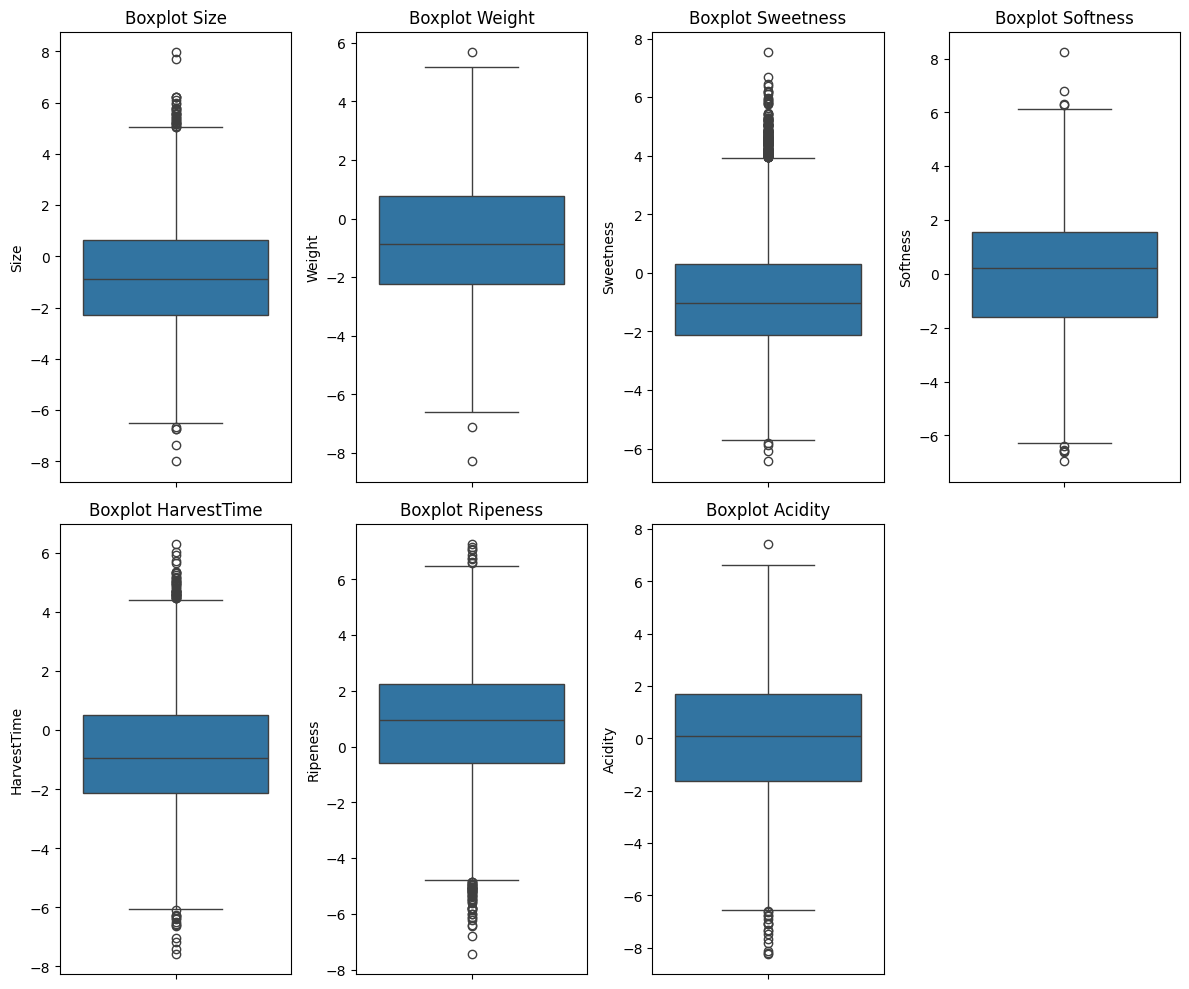

In [ ]:
data.columns = data.columns.str.strip()

plt.figure(figsize=(12, 10))
numeric_cols = ['Size', 'Weight', 'Sweetness', 'Softness', 'HarvestTime', 'Ripeness', 'Acidity']
for i, col in enumerate(numeric_cols):
    plt.subplot(2, 4, i+1)
    sns.boxplot(y=data[col])
    plt.title(f'Boxplot {col}', fontsize=12)
    plt.ylabel(col, fontsize=10)
plt.tight_layout()
plt.savefig('boxplot_fitur_numerik.png')
plt.show()

In [ ]:
def remove_outliers_iqr(df, columns):
    df_clean = df.copy()
    outliers_removed = 0

    for column in columns:
        Q1 = df_clean[column].quantile(0.25)
        Q3 = df_clean[column].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers_count = len(df_clean[(df_clean[column] < lower_bound) | (df_clean[column] > upper_bound)])
        outliers_removed += outliers_count
        print(f"Outliers di kolom {column}: {outliers_count} data")

        df_clean = df_clean[(df_clean[column] >= lower_bound) & (df_clean[column] <= upper_bound)]

    print(f"\nTotal outliers yang dihapus: {outliers_removed}")
    print(f"Data tersisa: {len(df_clean)} dari {len(df)} data asli")

    return df_clean

In [ ]:
numeric_columns = data.select_dtypes(include=[np.number]).columns.tolist()

data_clean = remove_outliers_iqr(data, numeric_columns)
data = data_clean.copy()

Outliers di kolom Size: 36 data
Outliers di kolom Weight: 3 data
Outliers di kolom Sweetness: 173 data
Outliers di kolom Softness: 6 data
Outliers di kolom HarvestTime: 54 data
Outliers di kolom Ripeness: 57 data
Outliers di kolom Acidity: 14 data

Total outliers yang dihapus: 343
Data tersisa: 7657 dari 8000 data asli


In [ ]:
print("\nDistribusi Target Variable (Quality):")
result_distribution = data['Quality'].value_counts()
print(result_distribution)
print(f"\nJumlah data Keseluruhan: {len(data)}")

for category in result_distribution.index:
    percentage = result_distribution[category]/len(data)*100
    print(f"Persentase buah pisang dengan quality {category}: {percentage:.2f}%")


Distribusi Target Variable (Quality):
Quality
Bad     3919
Good    3738
Name: count, dtype: int64

Jumlah data Keseluruhan: 7657
Persentase buah pisang dengan quality Bad: 51.18%
Persentase buah pisang dengan quality Good: 48.82%


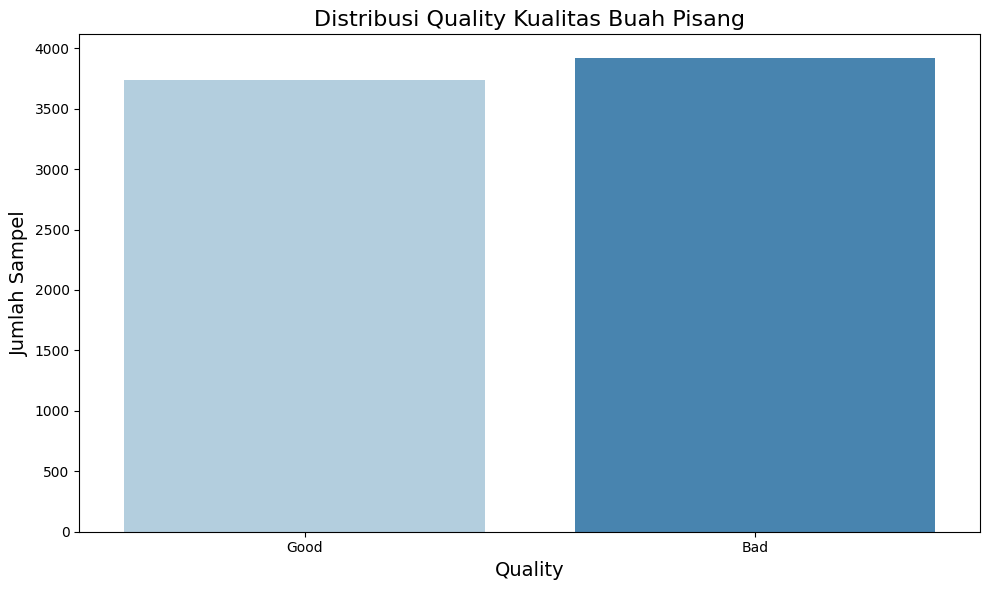

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Quality', data=data, hue='Quality', palette='Blues')
plt.title('Distribusi Quality Kualitas Buah Pisang', fontsize=16)
plt.xlabel('Quality', fontsize=14)
plt.ylabel('Jumlah Sampel', fontsize=14)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('distribusi_quality_kualitas.png')
plt.show()

<ipython-input-12-80dd85986d86>:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Quality', fontsize=10)
<ipython-input-12-80dd85986d86>:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Quality', fontsize=10)
<ipython-input-12-80dd85986d86>:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Quality', fontsize=10)
<ipython-input-12-80dd85986d86>:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Quality', fontsize=10)
<ipy

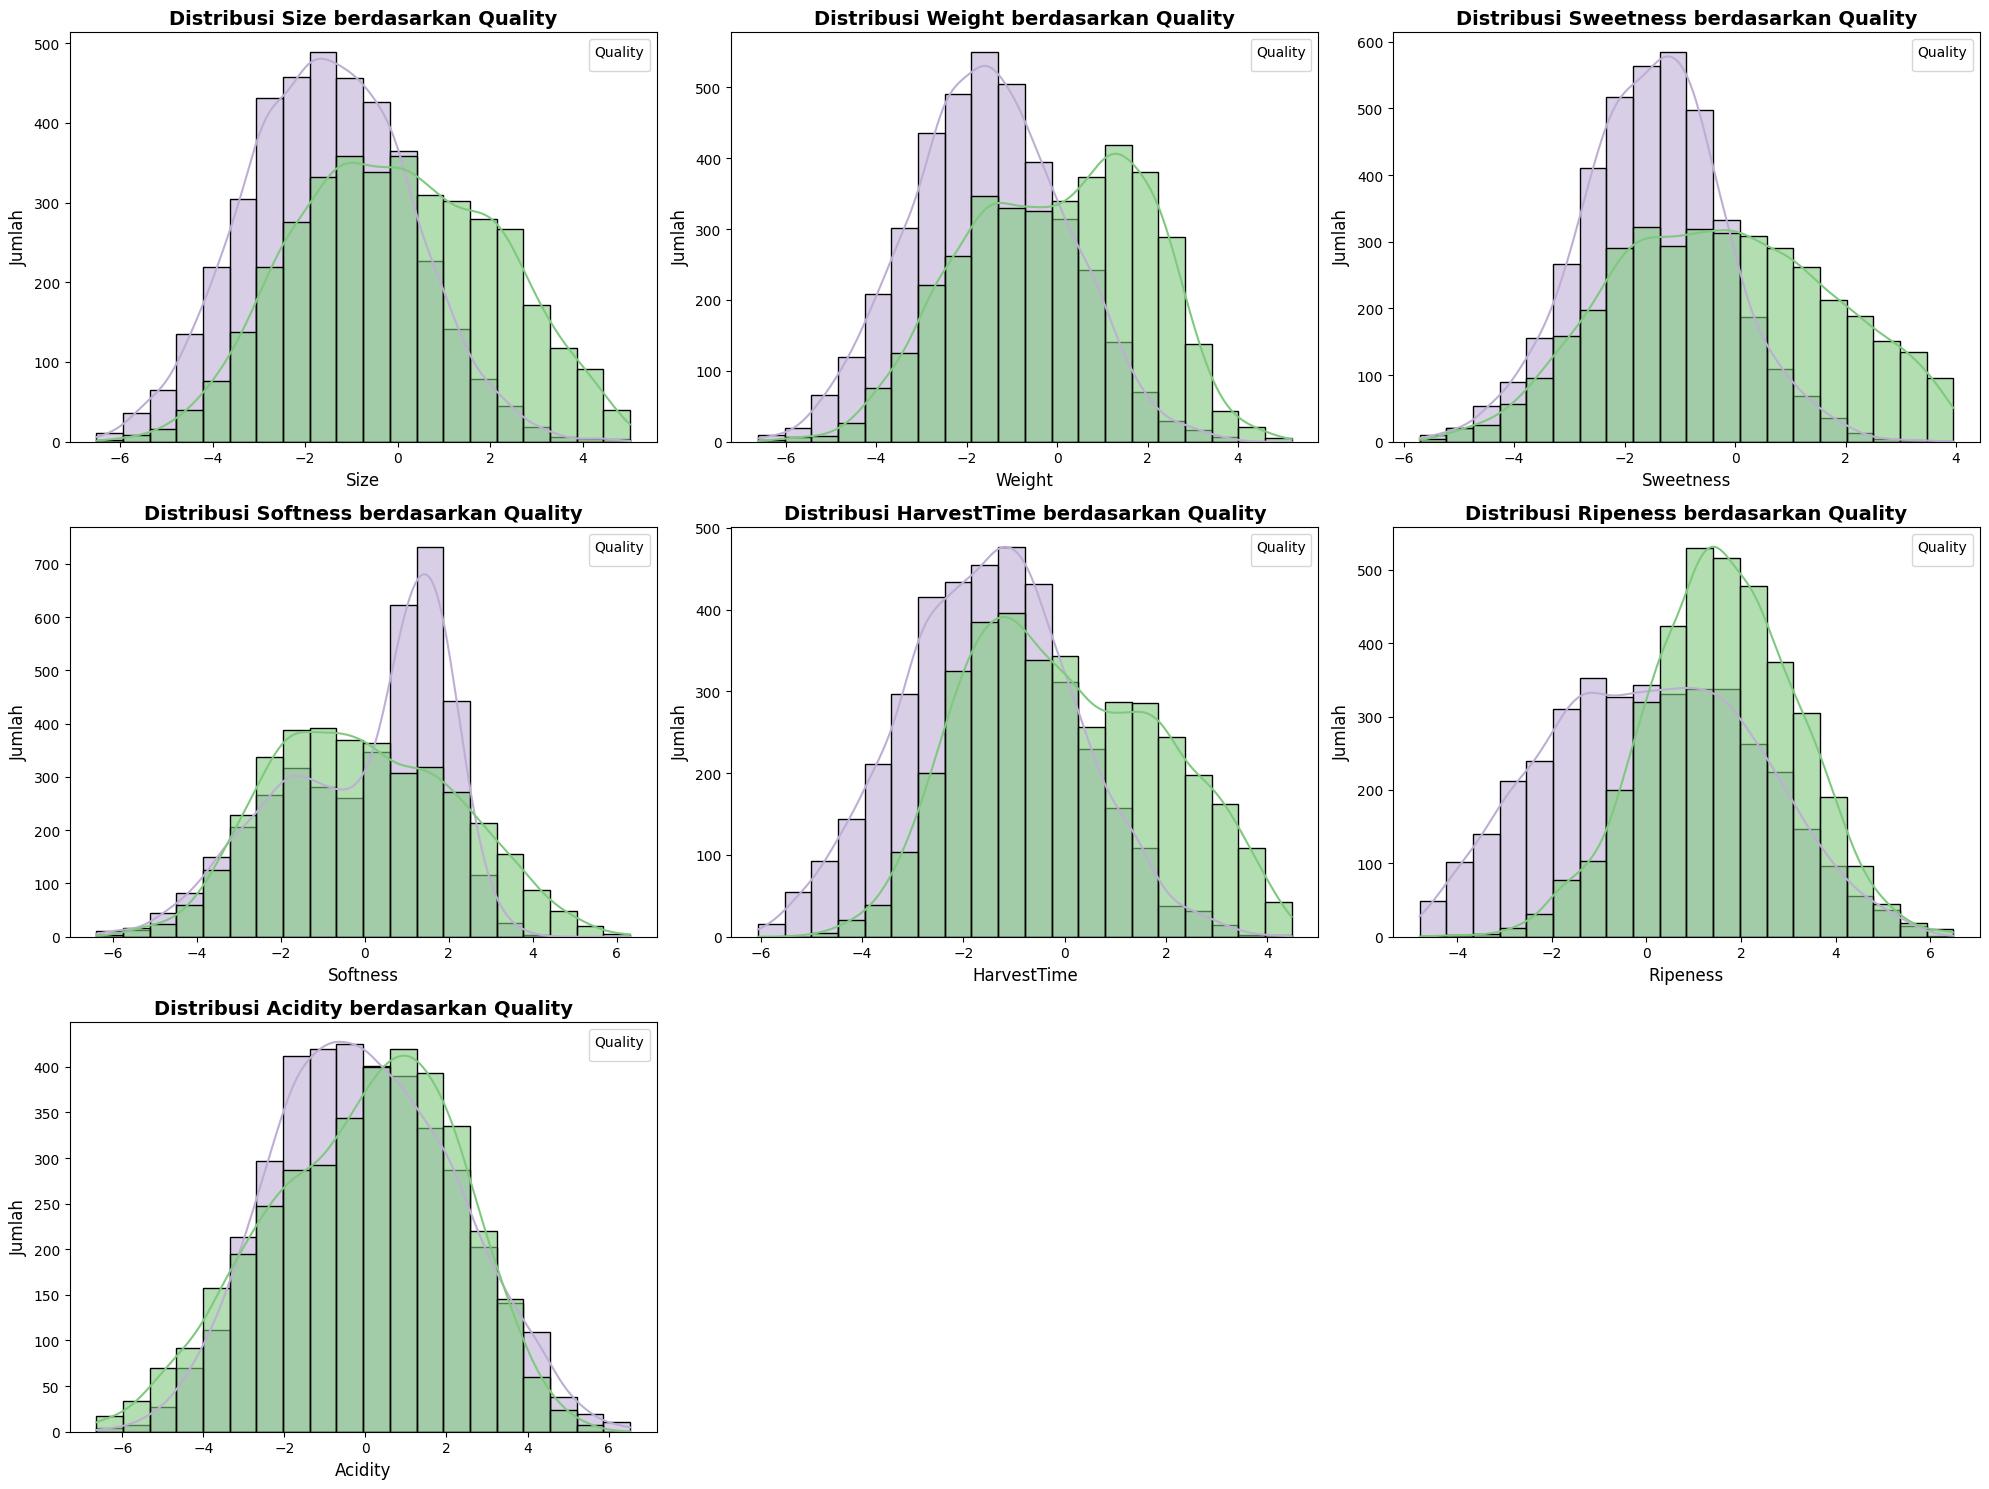

In [ ]:
plt.figure(figsize=(20, 15))
numerical_features = ['Size', 'Weight', 'Sweetness', 'Softness', 'HarvestTime', 'Ripeness', 'Acidity']
for i, column in enumerate(numerical_features):
    plt.subplot(3, 3, i+1)
    sns.histplot(data=data, x=column, hue='Quality', kde=True, palette='Accent',
                 bins=20, stat='count', alpha=0.6)
    plt.title(f'Distribusi {column} berdasarkan Quality', fontsize=14, weight='bold')
    plt.xlabel(f'{column}', fontsize=12)
    plt.ylabel('Jumlah', fontsize=12)
    plt.legend(title='Quality', fontsize=10)
plt.tight_layout()
plt.savefig('distribusi_variabel_numerik.png', dpi=300)
plt.show()


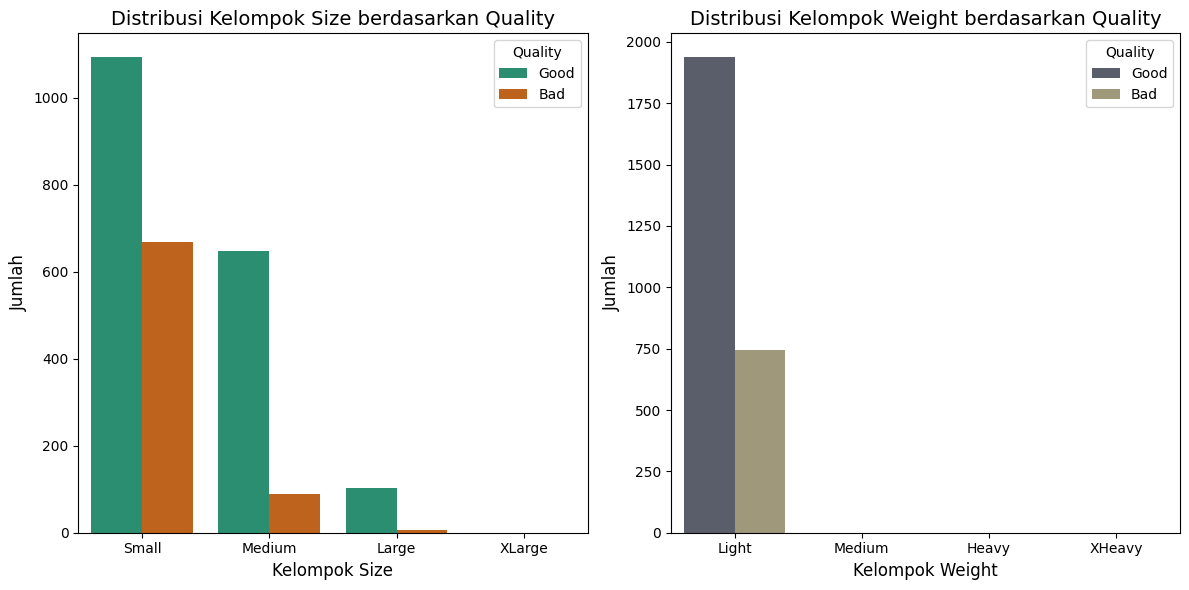

In [ ]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
data['Size_Group'] = pd.cut(data['Size'], bins=[0, 2, 4, 6, 10], labels=['Small', 'Medium', 'Large', 'XLarge'])
sns.countplot(x='Size_Group', hue='Quality', data=data, palette='Dark2')
plt.title('Distribusi Kelompok Size berdasarkan Quality', fontsize=14)
plt.xlabel('Kelompok Size', fontsize=12)
plt.ylabel('Jumlah', fontsize=12)

plt.subplot(1, 2, 2)
data['Weight_Group'] = pd.cut(data['Weight'], bins=[0, 100, 150, 200, 300], labels=['Light', 'Medium', 'Heavy', 'XHeavy'])
sns.countplot(x='Weight_Group', hue='Quality', data=data, palette='cividis')
plt.title('Distribusi Kelompok Weight berdasarkan Quality', fontsize=14)
plt.xlabel('Kelompok Weight', fontsize=12)
plt.ylabel('Jumlah', fontsize=12)

plt.tight_layout()
plt.savefig('distribusi_variabel_kategorik.png')
plt.show()

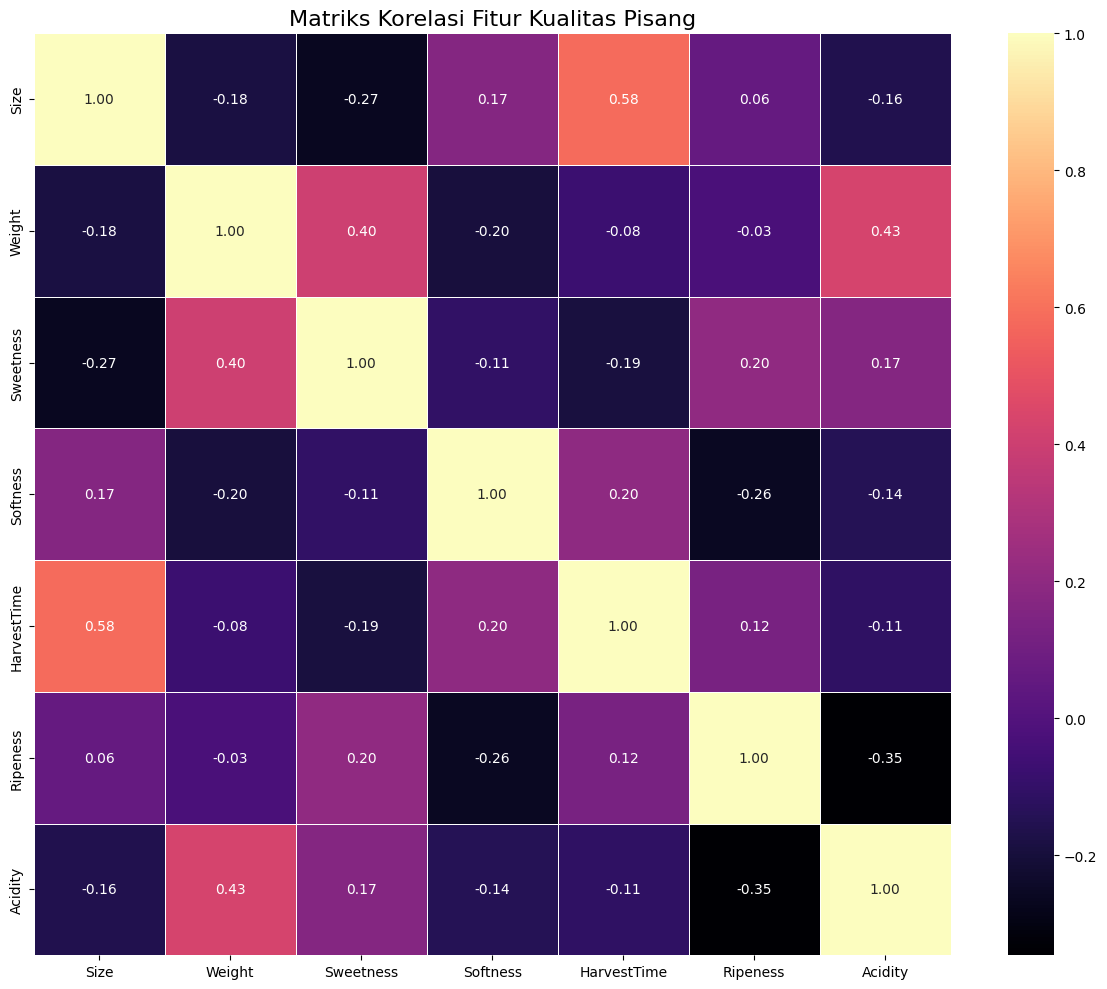

In [ ]:
numeric_data = data.select_dtypes(include=[np.number])
plt.figure(figsize=(12, 10))
correlation_matrix = numeric_data.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='magma', linewidths=0.5, fmt='.2f')
plt.title('Matriks Korelasi Fitur Kualitas Pisang', fontsize=16)
plt.tight_layout()
plt.savefig('matriks_korelasi_pisang.png')
plt.show()

In [ ]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(data['Quality'])
X = data.drop(['Quality', 'Size_Group', 'Weight_Group'], axis=1, errors='ignore')

numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Kolom dlm data:", numerical_cols)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Kolom dlm data: ['Size', 'Weight', 'Sweetness', 'Softness', 'HarvestTime', 'Ripeness', 'Acidity']


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
selector = SelectFromModel(RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5), threshold="mean")
X_train_selected = selector.fit_transform(X_train_scaled, y_train)
X_test_selected = selector.transform(X_test_scaled)

print(f"Jumlah fitur sebelum seleksi: {X_train_scaled.shape[1]}")
print(f"Jumlah fitur setelah seleksi: {X_train_selected.shape[1]}")

print(f"\nBentuk set pelatihan: {X_train.shape}")
print(f"Bentuk set pengujian: {X_test.shape}")

Jumlah fitur sebelum seleksi: 7
Jumlah fitur setelah seleksi: 5

Bentuk set pelatihan: (6125, 7)
Bentuk set pengujian: (1532, 7)


In [ ]:
print("\nDistribusi kelas pada data training:")
unique, counts = np.unique(y_train, return_counts=True)
for i, (cls, count) in enumerate(zip(label_encoder.classes_, counts)):
    print(f"{cls}: {count} ({count/len(y_train)*100:.1f}%)")

print("\nDistribusi kelas pada data testing:")
unique, counts = np.unique(y_test, return_counts=True)
for i, (cls, count) in enumerate(zip(label_encoder.classes_, counts)):
    print(f"{cls}: {count} ({count/len(y_test)*100:.1f}%)")


Distribusi kelas pada data training:
Bad: 3135 (51.2%)
Good: 2990 (48.8%)

Distribusi kelas pada data testing:
Bad: 784 (51.2%)
Good: 748 (48.8%)


In [ ]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_selected, y_train)

print("\nDistribusi sebelum SMOTE:")
unique, counts = np.unique(y_train, return_counts=True)
for cls, count in zip(label_encoder.classes_, counts):
    print(f"{cls}: {count}")

print("\nDistribusi setelah SMOTE:")
unique, counts = np.unique(y_train_smote, return_counts=True)
for cls, count in zip(label_encoder.classes_, counts):
    print(f"{cls}: {count}")


Distribusi sebelum SMOTE:
Bad: 3135
Good: 2990

Distribusi setelah SMOTE:
Bad: 3135
Good: 3135


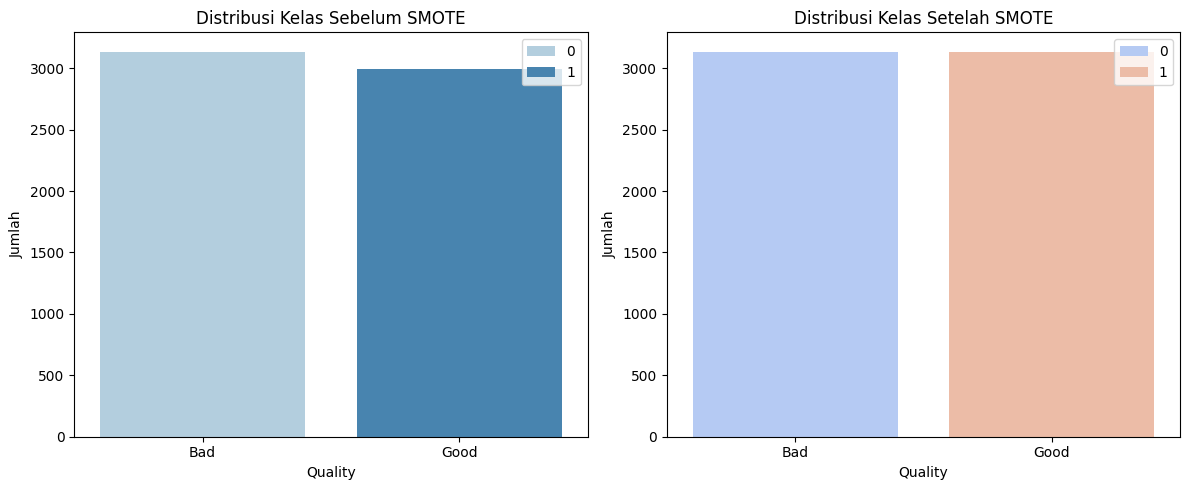

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(x=y_train, hue=y_train, palette='Blues')
plt.title("Distribusi Kelas Sebelum SMOTE")
plt.xlabel("Quality")
plt.ylabel("Jumlah")
plt.xticks(range(len(label_encoder.classes_)), label_encoder.classes_, rotation=0)

plt.subplot(1, 2, 2)
sns.countplot(x=y_train_smote, hue=y_train_smote, palette='coolwarm')
plt.title("Distribusi Kelas Setelah SMOTE")
plt.xlabel("Quality")
plt.ylabel("Jumlah")
plt.xticks(range(len(label_encoder.classes_)), label_encoder.classes_, rotation=0)

plt.tight_layout()
plt.savefig("distribusi_setelah_smote_pisang.png")
plt.show()

In [ ]:
def plot_matriks_konfusi(y_true, y_pred, title="Model"):
    labels = sorted(list(set(y_true)))
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
                xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)

    plt.xlabel("Label Prediksi")
    plt.ylabel("Label Sebenarnya")
    plt.title(f"Matriks Konfusi - {title}")
    plt.tight_layout()
    plt.show()

In [ ]:
param_grid_dt_improved = {
    'max_depth': [3, 4, 5, 6],  # Lebih shallow untuk mengurangi overfitting
    'min_samples_split': [15, 20, 25, 30],  # Lebih tinggi untuk generalisasi lebih baik
    'min_samples_leaf': [8, 10, 12, 15],  # Lebih tinggi untuk menghindari leaf yang terlalu spesifik
    'criterion': ['gini', 'entropy'],
    'max_features': ['sqrt', 'log2'],  # Menghilangkan None untuk mengurangi kompleksitas
    'min_impurity_decrease': [0.001, 0.005, 0.01]  # Menambahkan constraint tambahan
}

print("=== IMPROVED DECISION TREE HYPERPARAMETER TUNING ===")
print("Menggunakan parameter yang lebih konservatif untuk mengurangi overfitting...")

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_dt_improved = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt_improved,
    cv=cv_strategy,
    scoring='f1_weighted',
    n_jobs=-1
)
grid_dt_improved.fit(X_train_smote, y_train_smote)

dt_model_improved = grid_dt_improved.best_estimator_
dt_model_improved.fit(X_train_smote, y_train_smote)

=== IMPROVED DECISION TREE HYPERPARAMETER TUNING ===
Menggunakan parameter yang lebih konservatif untuk mengurangi overfitting...


DecisionTreeClassifier(max_depth=6, max_features='sqrt',
                       min_impurity_decrease=0.001, min_samples_leaf=8,
                       min_samples_split=25, random_state=42)

In [ ]:
dt_train_pred_improved = dt_model_improved.predict(X_train_smote)

dt_accuracy_improved = accuracy_score(y_train_smote, dt_train_pred_improved)
dt_precision_improved = precision_score(y_train_smote, dt_train_pred_improved, average='weighted')
dt_recall_improved = recall_score(y_train_smote, dt_train_pred_improved, average='weighted')
dt_f1_improved = f1_score(y_train_smote, dt_train_pred_improved, average='weighted')

print("\n=== IMPROVED DECISION TREE - TRAINING RESULTS ===")
print("Metrik Evaluasi Improved Decision Tree pada Data Training")
print(f"Akurasi: {dt_accuracy_improved:.4f}")
print(f"Presisi: {dt_precision_improved:.4f}")
print(f"Recall: {dt_recall_improved:.4f}")
print(f"F1-Score: {dt_f1_improved:.4f}")


=== IMPROVED DECISION TREE - TRAINING RESULTS ===
Metrik Evaluasi Improved Decision Tree pada Data Training
Akurasi: 0.8860
Presisi: 0.8860
Recall: 0.8860
F1-Score: 0.8860


In [ ]:
dt_test_pred_improved = dt_model_improved.predict(X_test_selected)

dt_test_accuracy_improved = accuracy_score(y_test, dt_test_pred_improved)
dt_test_precision_improved = precision_score(y_test, dt_test_pred_improved, average='weighted')
dt_test_recall_improved = recall_score(y_test, dt_test_pred_improved, average='weighted')
dt_test_f1_improved = f1_score(y_test, dt_test_pred_improved, average='weighted')

print("\n=== IMPROVED DECISION TREE - TESTING RESULTS ===")
print("Metrik Evaluasi Improved Decision Tree pada Data Testing")
print(f"Akurasi: {dt_test_accuracy_improved:.4f}")
print(f"Presisi: {dt_test_precision_improved:.4f}")
print(f"Recall: {dt_test_recall_improved:.4f}")
print(f"F1-Score: {dt_test_f1_improved:.4f}")


=== IMPROVED DECISION TREE - TESTING RESULTS ===
Metrik Evaluasi Improved Decision Tree pada Data Testing
Akurasi: 0.8642
Presisi: 0.8648
Recall: 0.8642
F1-Score: 0.8642


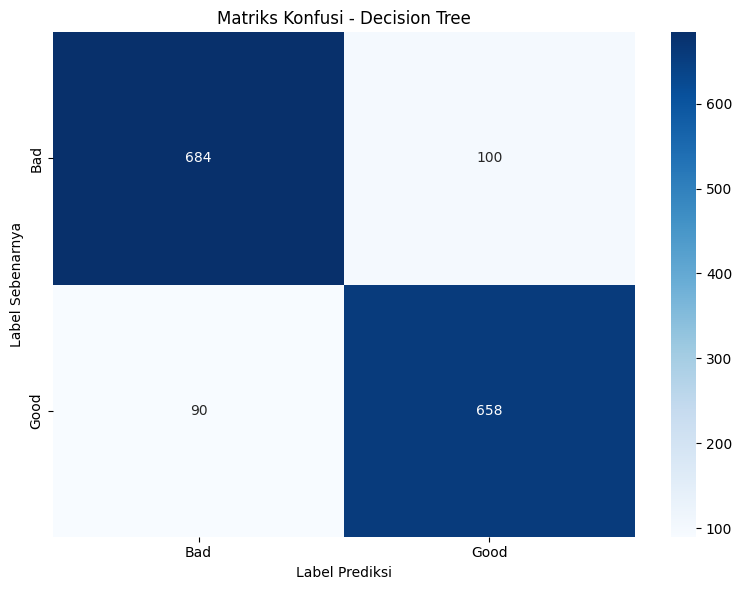

In [ ]:
plot_matriks_konfusi(y_test, dt_test_pred, "Decision Tree")

In [ ]:
param_grid_nb_improved = {
    'var_smoothing': [1e-10, 1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4]  # Range yang lebih fokus
}

grid_nb_improved = GridSearchCV(
    GaussianNB(),
    param_grid_nb_improved,
    cv=cv_strategy,
    scoring='f1_weighted',
    n_jobs=-1
)

grid_nb_improved.fit(X_train_smote, y_train_smote)
nb_model_improved = grid_nb_improved.best_estimator_
nb_model_improved.fit(X_train_smote, y_train_smote)

GaussianNB(var_smoothing=1e-10)

In [ ]:
nb_train_pred_improved = nb_model_improved.predict(X_train_smote)

print("\n=== IMPROVED NAIVE BAYES - TRAINING RESULTS ===")
print("Metrik Evaluasi Improved Naive Bayes pada Data Training")
nb_train_accuracy_improved = accuracy_score(y_train_smote, nb_train_pred_improved)
nb_train_precision_improved = precision_score(y_train_smote, nb_train_pred_improved, average='weighted')
nb_train_recall_improved = recall_score(y_train_smote, nb_train_pred_improved, average='weighted')
nb_train_f1_improved = f1_score(y_train_smote, nb_train_pred_improved, average='weighted')

print(f"Akurasi: {nb_train_accuracy_improved:.4f}")
print(f"Presisi: {nb_train_precision_improved:.4f}")
print(f"Recall: {nb_train_recall_improved:.4f}")
print(f"F1-Score: {nb_train_f1_improved:.4f}")


=== IMPROVED NAIVE BAYES - TRAINING RESULTS ===
Metrik Evaluasi Improved Naive Bayes pada Data Training
Akurasi: 0.8839
Presisi: 0.8845
Recall: 0.8839
F1-Score: 0.8838


In [ ]:
nb_test_pred_improved = nb_model_improved.predict(X_test_selected)

print("\n=== IMPROVED NAIVE BAYES - TESTING RESULTS ===")
print("Metrik Evaluasi Improved Naive Bayes pada Data Testing")
nb_accuracy_improved = accuracy_score(y_test, nb_test_pred_improved)
nb_precision_improved = precision_score(y_test, nb_test_pred_improved, average='weighted')
nb_recall_improved = recall_score(y_test, nb_test_pred_improved, average='weighted')
nb_f1_improved = f1_score(y_test, nb_test_pred_improved, average='weighted')

print(f"Akurasi: {nb_accuracy_improved:.4f}")
print(f"Presisi: {nb_precision_improved:.4f}")
print(f"Recall: {nb_recall_improved:.4f}")
print(f"F1-Score: {nb_f1_improved:.4f}")


=== IMPROVED NAIVE BAYES - TESTING RESULTS ===
Metrik Evaluasi Improved Naive Bayes pada Data Testing
Akurasi: 0.8708
Presisi: 0.8718
Recall: 0.8708
F1-Score: 0.8708


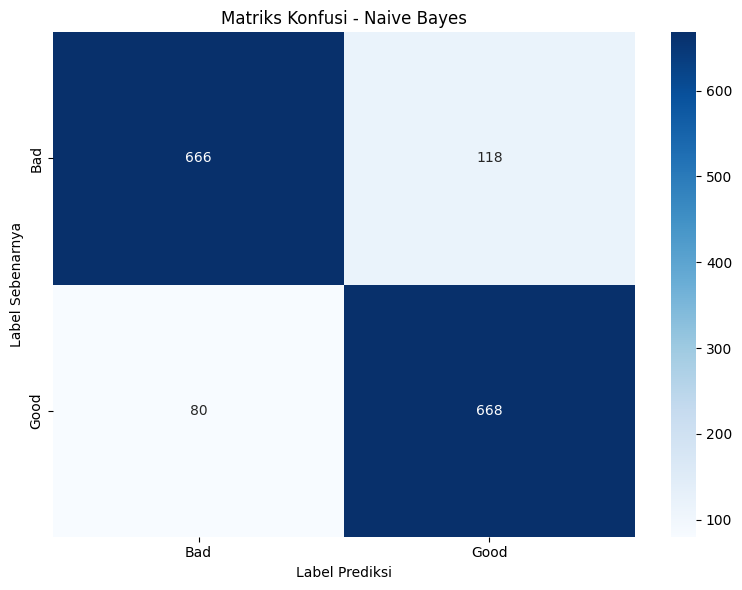

In [ ]:
plot_matriks_konfusi(y_test, nb_test_pred, "Naive Bayes")

In [ ]:
dt_metrics = [dt_test_accuracy, dt_test_precision, dt_test_recall, dt_test_f1]
nb_metrics = [nb_accuracy, nb_precision, nb_recall, nb_f1]

performance_df = pd.DataFrame({
    'Decision Tree': dt_metrics,
    'Naive Bayes': nb_metrics,
}, index=['Akurasi', 'Presisi', 'Recall', 'F1-Score'])

performance_df.head()

,Decision Tree,Naive Bayes
Akurasi,0.875979,0.870757
Presisi,0.876081,0.871821
Recall,0.875979,0.870757
F1-Score,0.875993,0.870753
